# Welcome to RISK Quickstart

This notebook provides a minimal working example of **RISK (Regional Inference of Significant Kinships)**—a framework for **clustering**, **overrepresentation analysis**, and **visualization** of biological networks.  

In this Quickstart, we apply RISK to the **yeast protein–protein interaction (PPI) network** from Michaelis _et al._ (2023), which includes **3,839 proteins** and **30,955 interactions**. This dataset illustrates how RISK detects functional modules, performs overrepresentation testing, and visualizes the organization of cellular processes.  

You will learn how to:  
- **Cluster** the network using algorithms such as Louvain or Leiden.  
- **Test** for functional **overrepresentation** using hypergeometric and permutation-based methods.  
- **Visualize** modules with contour overlays and clean, publication-ready layouts.  

For a complete walkthrough and additional examples, see the [RISK documentation](https://riskportal.github.io/risk-docs/).

In [3]:
# Import RISK
import risk as r
from risk import RISK

# Import standard libraries
import os
from pathlib import Path

# Print RISK version
print(f"RISK version: {r.__version__}")

# Set working directory if running in a Binder / notebook environment
if "__file__" not in globals():
    os.chdir(Path().resolve())

# Enable inline plotting for notebooks
%matplotlib inline

RISK version: 0.0.15


---

## Initialize RISK

First, we initialize the RISK package.

In [4]:
# Initialize RISK
risk = RISK(verbose=True)

---

## Load Networks into RISK

Next, we load a network file into RISK for analysis.

RISK supports loading networks from multiple formats, including:

- Cytoscape files (`.cys`)
- Cytoscape JSON files (`.cyjs`)
- GPickle files (`.gpickle`)
- NetworkX graphs

In this quickstart, we demonstrate loading a Cytoscape `.cys` file.


In [3]:
# Load the network from a Cytoscape file for RISK analysis
network = risk.load_network_cytoscape(
    filepath="./data/cytoscape/michaelis_2023.cys",
    source_label="source",
    target_label="target",
    compute_sphere=True,
    surface_depth=0.1,
    min_edges_per_node=1,
)

---------------
Loading network
---------------
Filetype: Cytoscape
Filepath: ./data/cytoscape/michaelis_2023.cys
Minimum edges per node: 1
Projection: Sphere
Surface depth: 0.1
Initial node count: 3839
Final node count: 3839
Initial edge count: 30955
Final edge count: 30955


---

## Loading Annotations into RISK

We then link biological annotations to the network nodes.

RISK supports loading annotations from various formats, including:

- JSON files (`.json`)
- CSV files (`.csv`)
- TSV files (`.tsv`)
- Excel spreadsheets (`.xlsx`, `.xls`)
- In-memory Python dictionaries

This quickstart demonstrates loading annotations from a JSON `.json` file.

In [4]:
# Load GO Biological Process (BP) annotations from a JSON file and associate with the network
annotation = risk.load_annotation_json(
    network=network,
    filepath="./data/json/annotation/go_biological_process.json",
    min_nodes_per_term=5,
    max_nodes_per_term=75,
)

------------------
Loading annotation
------------------
Filetype: JSON
Filepath: ./data/json/annotation/go_biological_process.json
Minimum number of nodes per annotation term: 5
Maximum number of nodes per annotation term: 75
Number of input annotation terms: 2214
Number of remaining annotation terms: 1293


---

## Clustering Algorithms and Statistical Methods

With the network and annotation ready, RISK first clusters the network into modules and then tests for overrepresentation of biological terms within them.

RISK supports several clustering algorithms:

- Louvain (fast, scalable for large networks)  
- Leiden (fast, improved Louvain with better connectivity)  
- Markov Clustering (medium, good for dense complexes)  
- Walktrap (medium, hierarchical/local structure)  
- Greedy Modularity (fast, coarse partitioning)  
- Label Propagation (fast, quick heuristic)  
- Spinglass (slow, theoretical, small networks)  

RISK also supports several statistical tests for annotation overrepresentation or depletion:

- Permutation test (robust, distribution-free)  
- Hypergeometric test (standard for GO/pathway overrepresentation)  
- Chi-squared test (fast approximation for large samples)  
- Binomial test (scalable approximation to hypergeometric)  

This Quickstart demonstrates the **permutation test**, which reshuffles network structure to assess statistical significance.

In [ ]:
# Perform annotation significance analysis using the permutation test
neighborhoods = risk.load_neighborhoods_permutation(
    network=network,
    annotation=annotation,
    clustering="louvain",
    louvain_resolution=5.0,
    leiden_resolution=1.0,
    fraction_shortest_edges=0.225,
    score_metric="stdev",
    null_distribution="network",
    num_permutations=1000,
    random_seed=887,
    max_workers=1,
)

------------------------
Running permutation test
------------------------
Neighborhood scoring metric: 'stdev'
Number of permutations: 1000
Maximum workers: 1
Null distribution: 'network'
Distance metric: 'louvain (resolution=5.0)'
Edge length threshold: 0.225
Random seed: 887


Total progress: 100%|██████████| 1000/1000 [00:23<00:00, 43.18it/s]


---

## Build and Analyze Results

We now create a processed graph object that integrates network structure, annotations, and statistical results into a single framework.  

The `load_graph` function generates a `NetworkGraph` for downstream analysis and visualization. After building the graph, you can access domain mappings, node labels, and significance scores for further exploration.

In [ ]:
# Generate a NetworkGraph for analysis
graph = risk.load_graph(
    network=network,
    annotation=annotation,
    neighborhoods=neighborhoods,
    tail="right",
    pval_cutoff=0.01,
    fdr_cutoff=1.00,
    impute_depth=0,
    prune_threshold=0.1,
    linkage_criterion="distance",
    linkage_method="single",
    linkage_metric="sokalmichener",
    linkage_threshold=0.063,
    min_cluster_size=5,
    max_cluster_size=1_000,
)

# Access important NetworkGraph attributes
domain_id_to_node_ids_map = graph.domain_id_to_node_ids_map
domain_id_to_node_labels_map = graph.domain_id_to_node_labels_map
domain_id_to_domain_terms_map = graph.domain_id_to_domain_terms_map
node_label_to_significance_map = graph.node_label_to_significance_map

---------------------------------
Finding significant neighborhoods
---------------------------------
p-value cutoff: 0.01
FDR BH cutoff: 1.0
Significance tail: 'right' (enrichment)
------------------------
Processing neighborhoods
------------------------
Imputation depth: 0
Pruning threshold: 0.1
-----------------------
Finding top annotations
-----------------------
Min cluster size: 5
Max cluster size: 1000
-----------------------------------------
Optimizing distance threshold for domains
-----------------------------------------


Evaluating linkage methods and metrics: 100%|█████████████████████████████████████████| 1/1 [00:00<00:00]

Linkage criterion: 'distance'
Linkage method: 'single'
Linkage metric: 'sokalmichener'
Linkage threshold: 0.063


---

## Summarize Analysis Results

The `summary.load()` method processes network annotations and significance scores into a pandas DataFrame for exploration.

In [11]:
# Load analysis summary into a DataFrame
loaded_summary = graph.summary.load()
loaded_summary.head()

------------------------
Loading analysis summary
------------------------


,Annotation,Domain ID,Matched Members,Matched Count,Summed Significance Score,Enrichment P-value,Enrichment Q-value,Depletion P-value,Depletion Q-value
0,maintenance of protein location in cell,27,BRE5;DID4;EMP24;EPS1;ERD2;ERP1;ERP2;ERP3;ERP4;...,28,90.0,0.001,0.099462,0.986,1.0
1,mRNA splice site recognition,20,CDC40;ISY1;LUC7;NAM8;PRP28;PRP39;PRP42;PRP8;PR...,11,189.0,0.001,0.215500,1.000,1.0
2,transsulfuration,-1,,0,0.0,1.000,1.000000,1.000,1.0
3,signal peptide processing,-1,,0,0.0,1.000,1.000000,1.000,1.0
4,regulation of phosphatidylinositol dephosphory...,-1,,0,0.0,1.000,1.000000,1.000,1.0


---

## Visualize the Network

Finally, let's visualize the clustered network.

RISK provides flexible plotting tools to customize:

- Background color and figure size  
- Title, subtitle, and perimeter  
- Node and edge styles  
- Labels for major clusters  

All settings can be combined into a single publication-ready plot.

---------------
Loading plotter
---------------


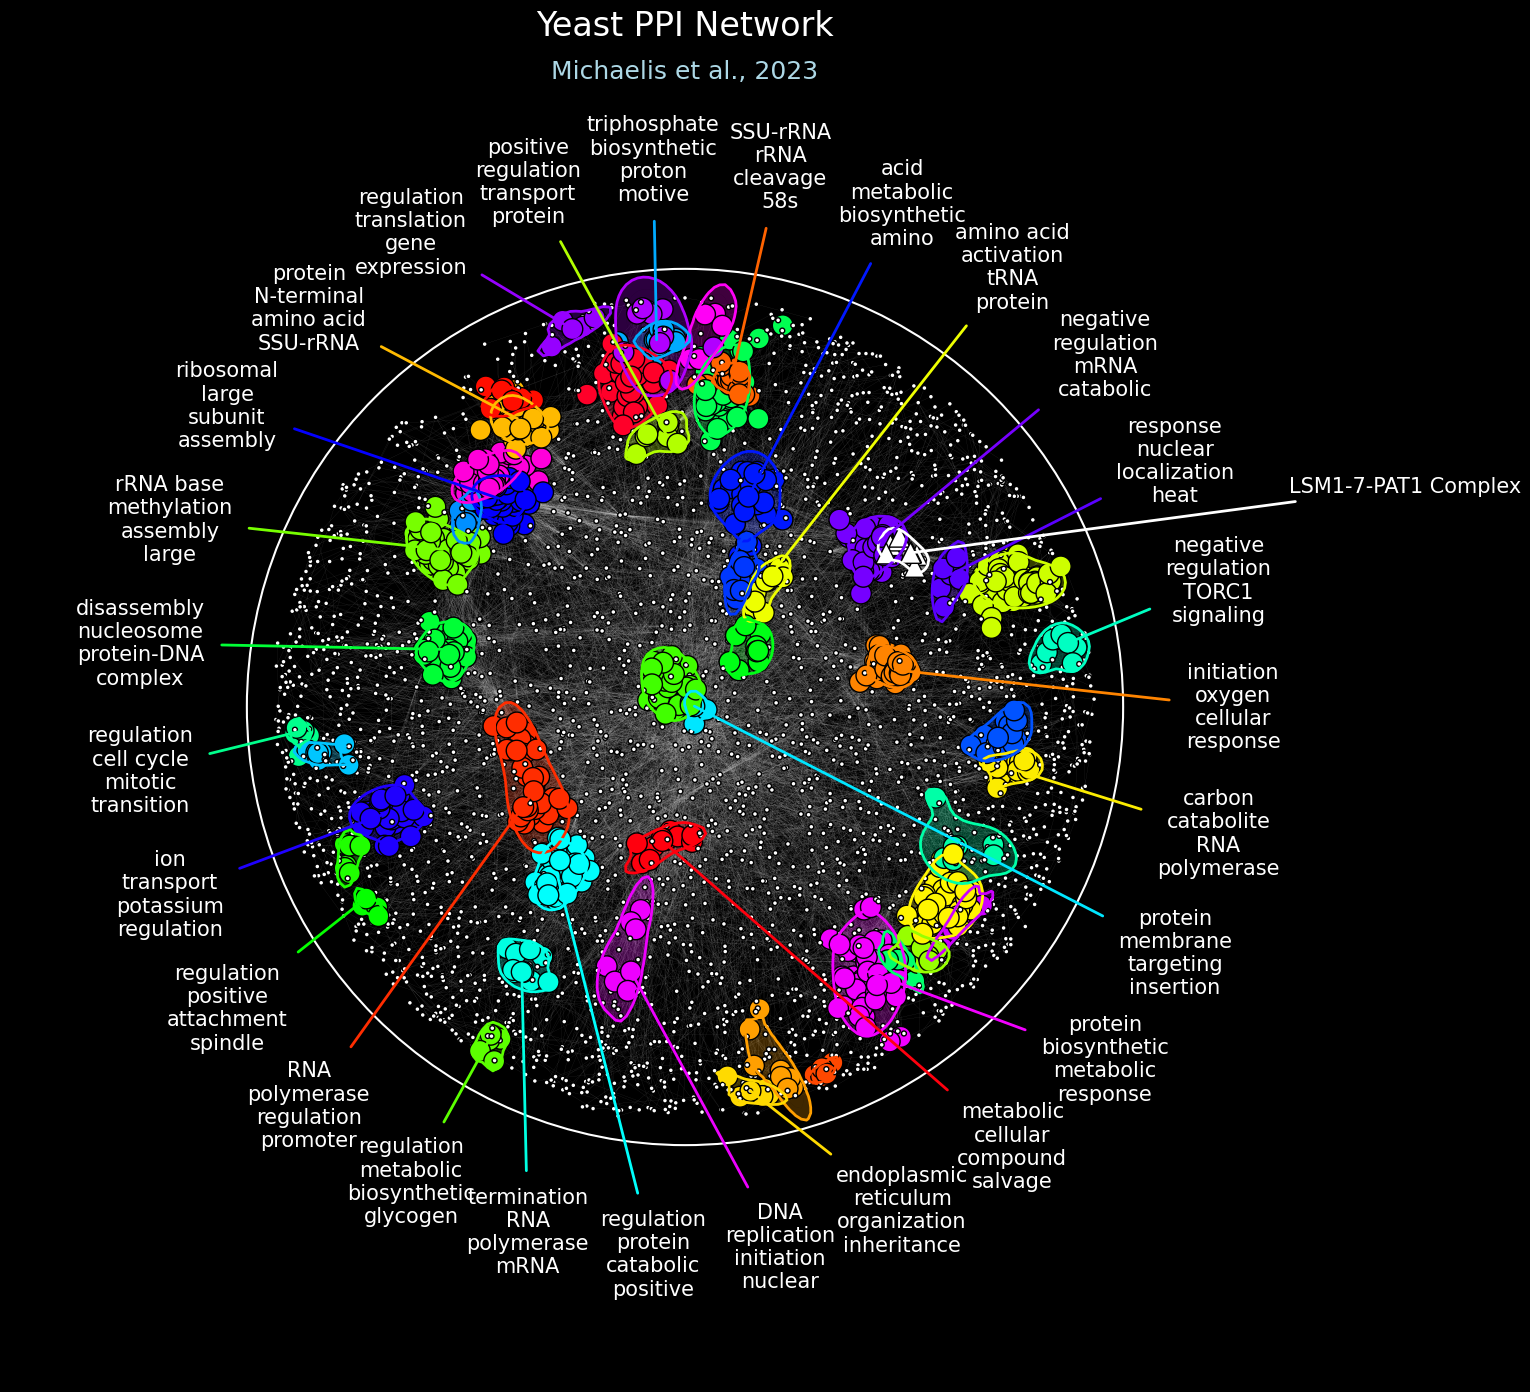

In [ ]:
# Build full network plot
import matplotlib.pyplot as plt

plt.ioff()

# Set random seed for reproducibility
random_seed = 887

# Initialize the NetworkPlotter with the NetworkGraph object
plotter = risk.load_plotter(
    graph=graph,
    figsize=(15, 15),
    background_color="black",
)

# Plot network title and subtitle
plotter.plot_title(
    title="Yeast PPI Network",
    subtitle="Michaelis et al., 2023",
    title_fontsize=24,
    subtitle_fontsize=18,
    font="DejaVu Sans",
    title_color="white",
    subtitle_color="lightblue",
    title_x=0.5,
    title_y=0.925,
    title_space_offset=0.08,
    subtitle_offset=0.025,
)

# Plot network perimeter as a circle
plotter.plot_circle_perimeter(
    scale=1.02,
    center_offset_x=0.0,
    center_offset_y=0.0,
    linestyle="solid",
    linewidth=1.5,
    color="white",
    outline_alpha=1.0,
    fill_alpha=0.0,
)

# Plot network nodes and edges
plotter.plot_network(
    node_size=plotter.get_annotated_node_sizes(
        significant_size=225,
        nonsignificant_size=12.5,
    ),
    node_shape="o",
    node_edgewidth=1.0,
    edge_width=0.03,
    node_color=plotter.get_annotated_node_colors(
        cmap="gist_rainbow",
        color=None,
        blend_colors=False,
        blend_gamma=2.2,
        min_scale=1.0,
        max_scale=1.0,
        scale_factor=0.5,
        alpha=1.0,
        nonsignificant_color="white",
        nonsignificant_alpha=0.75,
        ids_to_colors={
            10: "#f200ff",
            32: "#fcec00",
        },
        random_seed=random_seed,
    ),
    node_edgecolor="black",
    edge_color="white",
    node_alpha=1.0,
    edge_alpha=1.0,
)
# Plot a subnetwork with custom node and edge attributes
plotter.plot_subnetwork(
    nodes=[
        "LSM1",
        "LSM2",
        "LSM3",
        "LSM4",
        "LSM5",
        "LSM6",
        "LSM7",
        "PAT1",
    ],
    node_size=225,
    node_shape="^",
    node_edgewidth=1.0,
    edge_width=0.04,
    node_color="white",
    node_edgecolor="black",
    edge_color="white",
    node_alpha=1.0,
    edge_alpha=1.0,
)

# Plot Kernel Density Estimation (KDE)-based contours around network nodes
plotter.plot_contours(
    levels=5,
    bandwidth=0.8,
    grid_size=250,
    color=plotter.get_annotated_contour_colors(
        cmap="gist_rainbow",
        color=None,
        blend_colors=False,
        blend_gamma=2.2,
        min_scale=1.0,
        max_scale=1.0,
        scale_factor=0.5,
        ids_to_colors={
            10: "#f200ff",
            32: "#fcec00",
        },
        random_seed=random_seed,
    ),
    linestyle="solid",
    linewidth=2.0,
    alpha=1.0,
    fill_alpha=0.25,
)

# Plot custom KDE-based contours around a subset of nodes
plotter.plot_subcontour(
    nodes=[
        "LSM1",
        "LSM2",
        "LSM3",
        "LSM4",
        "LSM5",
        "LSM6",
        "LSM7",
        "PAT1",
    ],
    levels=5,
    bandwidth=0.8,
    grid_size=250,
    color="white",
    linestyle="solid",
    linewidth=2.0,
    alpha=1.0,
    fill_alpha=0.25,
)

# Plot labels on the network
plotter.plot_labels(
    scale=1.1,
    offset=0.12,
    font="DejaVu Sans",
    fontcase={"title": "lower"},
    fontsize=15,
    fontcolor="white",
    fontalpha=1.0,
    arrow_linewidth=2.0,
    arrow_style="-",
    arrow_color=plotter.get_annotated_label_colors(
        cmap="gist_rainbow",
        color=None,
        blend_colors=False,
        blend_gamma=2.2,
        min_scale=1.0,
        max_scale=1.0,
        scale_factor=0.5,
        ids_to_colors={
            10: "#f200ff",
            32: "#fcec00",
        },
        random_seed=random_seed,
    ),
    arrow_alpha=1.0,
    arrow_base_shrink=10.0,
    arrow_tip_shrink=0.0,
    max_labels=28,
    min_label_lines=3,
    max_label_lines=4,
    min_chars_per_line=3,
    max_chars_per_line=12,
    words_to_omit=["from", "the", "into", "via", "novo", "process", "activity"],
    overlay_ids=False,
    ids_to_keep=None,
    ids_to_labels=None,
)

# Plot sublabels on the network
plotter.plot_sublabel(
    nodes=[
        "LSM1",
        "LSM2",
        "LSM3",
        "LSM4",
        "LSM5",
        "LSM6",
        "LSM7",
        "PAT1",
    ],
    label="LSM1-7-PAT1 Complex",
    radial_position=73,
    scale=1.6,
    offset=0.12,
    font="DejaVu Sans",
    fontsize=15,
    fontcolor="white",
    fontalpha=1.0,
    arrow_linewidth=2.0,
    arrow_style="-",
    arrow_color="white",
    arrow_alpha=1.0,
    arrow_base_shrink=10.0,
    arrow_tip_shrink=0.0,
)

# Display the plot
plotter.show()

---

## Overview of Parameters

RISK records key parameters for each analysis, including network settings, annotations, statistical tests, and plotting options. 
<br>
Parameters can be inspected or exported to support documentation and reproducibility.

In [ ]:
# Load and display analysis parameters
import pandas as pd
from IPython.display import display

loaded_params = risk.params.load()

# Display parameters in a tidy table
pd.set_option("display.max_colwidth", 200)
display(pd.DataFrame(list(loaded_params.items()), columns=["Parameter", "Value"]))
pd.reset_option("display.max_colwidth")

------------------
Loading parameters
------------------


,Parameter,Value
0,annotation,"{'filetype': 'JSON', 'filepath': './data/json/annotation/go_biological_process.json', 'min_nodes_per_term': 5, 'max_nodes_per_term': 75}"
1,datetime,2025-09-29 18:21:12
2,graph,"{'tail': 'right', 'pval_cutoff': 0.01, 'fdr_cutoff': 1.0, 'impute_depth': 0, 'prune_threshold': 0.1, 'linkage_criterion': 'distance', 'linkage_method': 'single', 'linkage_metric': 'sokalmichener',..."
3,neighborhoods,"{'distance_metric': 'louvain', 'louvain_resolution': 5.0, 'leiden_resolution': 1.0, 'fraction_shortest_edges': 0.225, 'statistical_test_function': 'permutation', 'null_distribution': 'network', 'r..."
4,network,"{'compute_sphere': True, 'surface_depth': 0.1, 'min_edges_per_node': 1, 'filetype': 'Cytoscape', 'filepath': './data/cytoscape/michaelis_2023.cys'}"
5,plotter,"{'figsize': (15, 15), 'background_color': 'black', 'background_alpha': 1.0, 'pad': 0.3, 'title': 'Yeast PPI Network', 'subtitle': 'Michaelis et al., 2023', 'title_fontsize': 24, 'subtitle_fontsize..."
